<a href="https://colab.research.google.com/github/hnur79997-stack/tugas-gambar-visi-komputer-/blob/main/ujicoba_visi_komputer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install scikit-image opencv-python


Saving apel.jpg to apel (1).jpg


(np.float64(-0.5), np.float64(1023.5), np.float64(682.5), np.float64(-0.5))

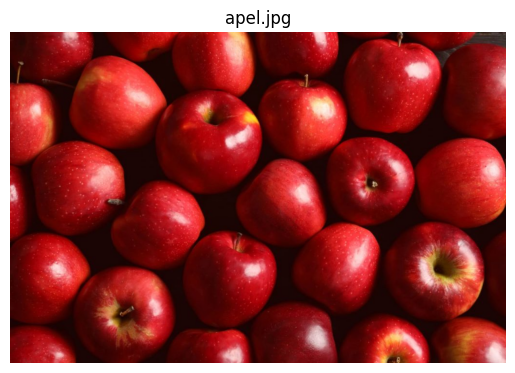

In [7]:
# Install library (jalankan sekali di Google Colab)
!pip install scikit-image opencv-python matplotlib

# Import Library
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import color
from skimage.segmentation import active_contour
from google.colab import files

# Upload dan Load Gambar
uploaded = files.upload()

image = cv2.imread(list(uploaded.keys())[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Tampilkan gambar
plt.imshow(image)
plt.title("apel.jpg")
plt.axis("off")

Text(0.5, 1.0, 'Thresholding')

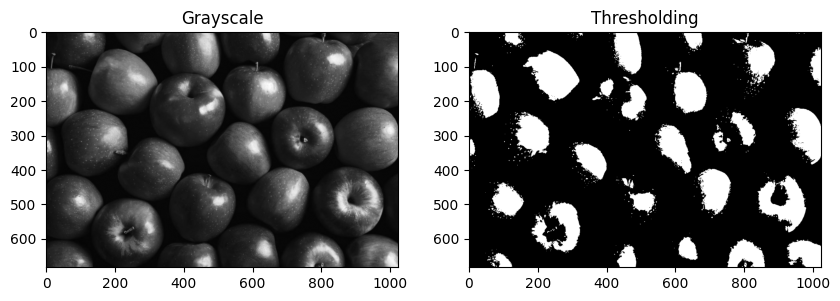

In [20]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Otsu Threshold
thresh_val = threshold_otsu(gray)
binary = gray > thresh_val

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")

plt.subplot(1,2,2)
plt.imshow(binary, cmap='gray')
plt.title("Thresholding")


(np.float64(-0.5), np.float64(1023.5), np.float64(682.5), np.float64(-0.5))

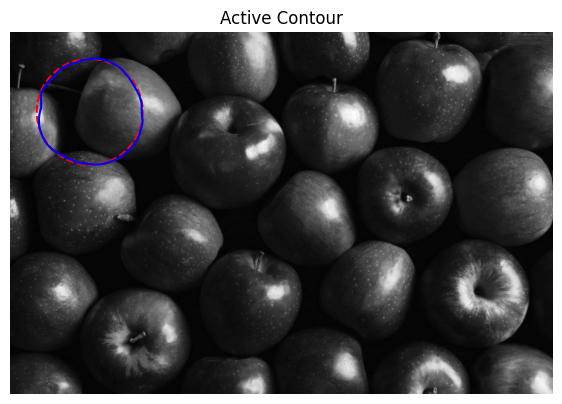

In [9]:
gray = color.rgb2gray(image)

# membuat lingkaran awal untuk snake
s = np.linspace(0, 2*np.pi, 400)
x = 150 + 100*np.cos(s)
y = 150 + 100*np.sin(s)
init = np.array([x, y]).T

snake = active_contour(gray,
                       init,
                       alpha=0.015,
                       beta=10,
                       gamma=0.001)

fig, ax = plt.subplots(figsize=(7,7))
ax.imshow(gray, cmap='gray')
ax.plot(init[:,0], init[:,1], '--r', label="Init")
ax.plot(snake[:,0], snake[:,1], '-b', label="Snake")
ax.set_title("Active Contour")
ax.axis('off')

Text(0.5, 1.0, 'Color Segmentation')

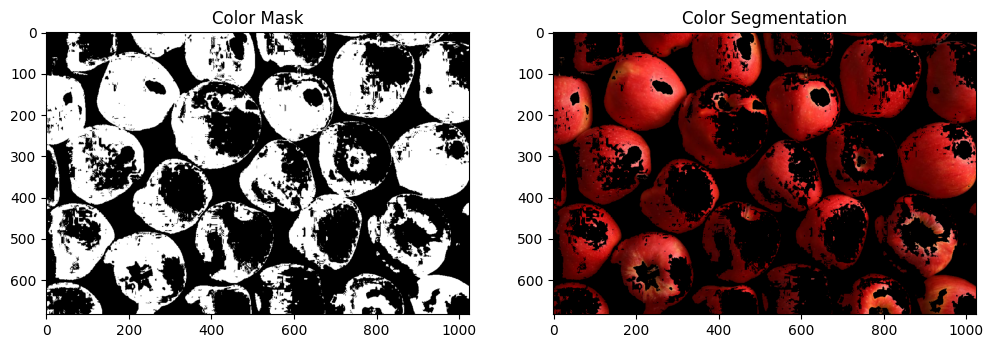

In [12]:
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

# contoh deteksi warna merah
lower = np.array([0,120,70])
upper = np.array([10,255,255])

mask_color = cv2.inRange(hsv, lower, upper)

result = cv2.bitwise_and(image,image,mask=mask_color)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(mask_color,cmap='gray')
plt.title("Color Mask")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Color Segmentation")


(np.float64(-0.5), np.float64(1023.5), np.float64(682.5), np.float64(-0.5))

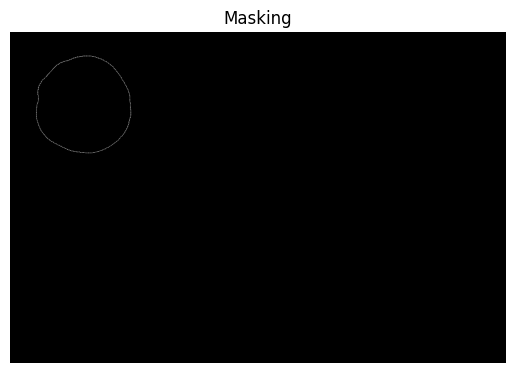

In [13]:
mask = np.zeros(gray.shape, dtype=np.uint8)
mask[snake[:,1].astype(int), snake[:,0].astype(int)] = 1

plt.imshow(mask, cmap='gray')
plt.title("Masking")
plt.axis("off")

(np.float64(-0.5), np.float64(1023.5), np.float64(682.5), np.float64(-0.5))

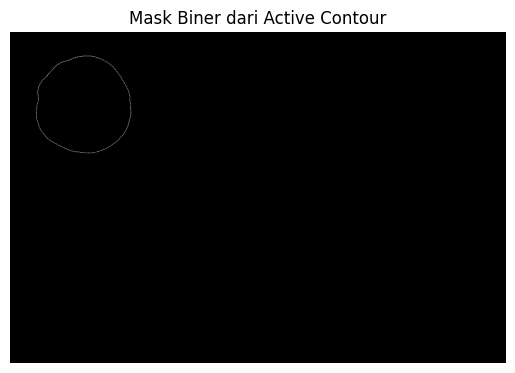

In [10]:
mask = np.zeros(gray.shape, dtype=np.uint8)

snake_x = snake[:,0].astype(int)
snake_y = snake[:,1].astype(int)

mask[snake_y, snake_x] = 255

plt.imshow(mask, cmap='gray')
plt.title("Mask Biner dari Active Contour")
plt.axis("off")

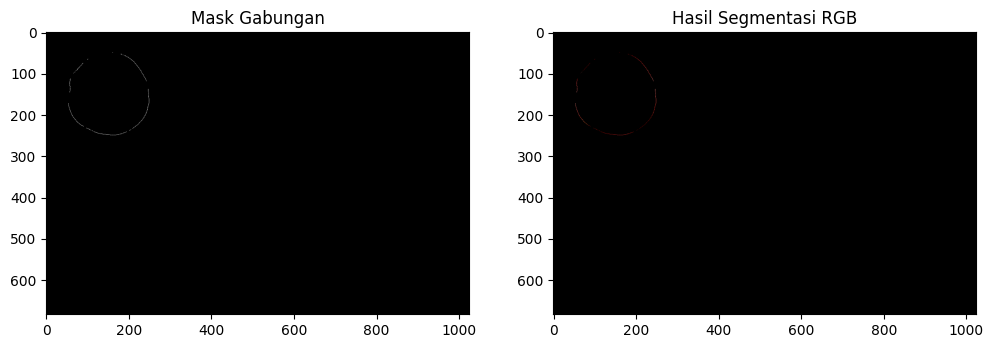

In [17]:
# gabungkan mask warna dan mask contour
combined_mask = cv2.bitwise_and(color_mask, mask)

# segmentasi RGB
segmented = cv2.bitwise_and(image, image, mask=combined_mask)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(combined_mask, cmap='gray')
plt.title("Mask Gabungan")

plt.subplot(1,2,2)
plt.imshow(segmented)
plt.title("Hasil Segmentasi RGB")

plt.show()

Saving apel.jpg to apel (2).jpg


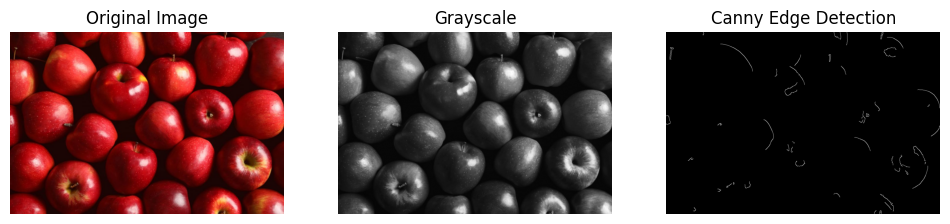

In [21]:
# Install library (jalankan sekali di Colab)
!pip install opencv-python matplotlib

# Import library
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload gambar
uploaded = files.upload()

# Membaca gambar
image = cv2.imread(list(uploaded.keys())[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Konversi ke grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Mengurangi noise dengan Gaussian Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Deteksi tepi menggunakan Canny
edges = cv2.Canny(blur, 100, 200)

# Menampilkan hasil
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")

plt.show()

Saving apel.jpg to apel (7).jpg


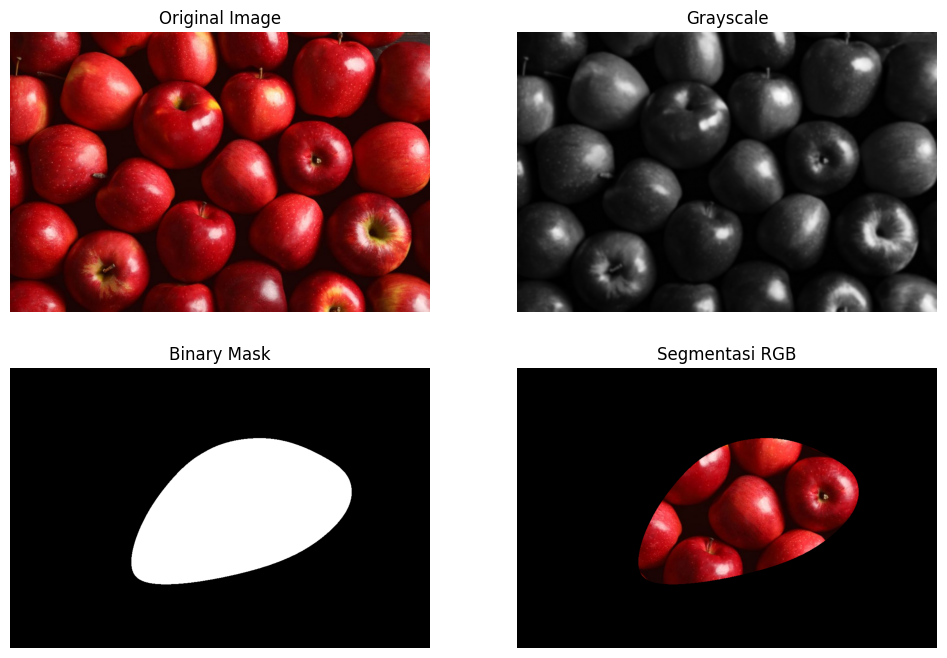

In [26]:
# Install library
!pip install scikit-image opencv-python matplotlib

# Import library
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import color
from skimage.segmentation import active_contour
from skimage.draw import polygon
from skimage.filters import gaussian
from google.colab import files

# Upload gambar
uploaded = files.upload()

# Load gambar
image = cv2.imread(list(uploaded.keys())[0])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert grayscale
gray = color.rgb2gray(image)

# Blur supaya kontur lebih jelas
gray = gaussian(gray, 2)

# Ambil ukuran gambar
h, w = gray.shape

# Inisialisasi snake mengikuti ukuran gambar
s = np.linspace(0, 2*np.pi, 400)
r = h/2 + h/3*np.sin(s)
c = w/2 + w/3*np.cos(s)
init = np.array([r, c]).T

# Active Contour
snake = active_contour(gray, init, alpha=0.01, beta=10, gamma=0.001)

# ====================
# Membuat mask biner
# ====================
mask = np.zeros(gray.shape, dtype=np.uint8)

rr, cc = polygon(snake[:,0], snake[:,1], mask.shape)
mask[rr, cc] = 255

# ====================
# Segmentasi RGB
# ====================
segmented = cv2.bitwise_and(image, image, mask=mask)

# ====================
# Tampilkan hasil
# ====================
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(segmented)
plt.title("Segmentasi RGB")
plt.axis("off")

plt.show()